<xarray.Dataset> Size: 6GB
Dimensions:           (time: 240, bnds: 2, lon: 3600, lat: 1800)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2019-11-01 ... 2019-11-30T21:...
  * lon               (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.9 179.9
  * lat               (lat) float32 7kB -89.95 -89.85 -89.75 ... 89.85 89.95
Dimensions without coordinates: bnds
Data variables:
    time_bnds         (time, bnds) datetime64[ns] 4kB ...
    precipitationCal  (time, lat, lon) float32 6GB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.5 (http://mpimet.mpg.de/...
    history:      Mon Sep 27 17:58:00 2021: cdo --timestat_date first -L -f n...
    Conventions:  CF-1.6
    FileHeader:   DOI=10.5067/GPM/IMERG/3B-HH/06;\nDOIauthority=http://dx.doi...
    FileInfo:     DataFormatVersion=6a;\nTKCodeBuildVersion=0;\nMetadataVersi...
    GridHeader:   BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeR...
    CDO:          Climate Data Operators version 1.9.5 (http://mpimet.mpg.de/...

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs 

# emplacement des données
path = "D:\\UQAM\\session_5\\labo_3\\Experience_1\\imerg_pr_201911_3h.nc4"
ds=xr.open_dataset(path)

#définition des coordonnées initiales

JakartaLon = 106.8
JakartaLat = -6.2 
QuebecLon = -71.2
QuebecLat = 46.8
OceanLon = 106.0
OceanLat = 7.0
LimaLon = -77.05
LimaLat = -12.05
MontrealLon = -73.57
MontrealLat = 45.57
 
lon = ds["lon"]
lat = ds["lat"]

#initialisation des listes contenant les longitudes ajustées
lonJ = []
lonQ = []
lonO = []
lonL = []
lonM = []

#boucle permettant de trouver le point de grille le plus près de la longitude de la ville. On fait la différence avec chaque longitude et on trouve l'indice du minimum pour aller chercher la longitude directement.
for i in lon:
    diffJ = JakartaLon - i
    diffQ = QuebecLon - i
    diffO = OceanLon - i
    diffL = LimaLon - i
    diffM = MontrealLon - i
    lonJ.append(diffJ)
    lonQ.append(diffQ)
    lonO.append(diffO)
    lonL.append(diffL)
    lonM.append(diffM)
lonJ_absolue = np.abs(lonJ)
lonQ_absolue = np.abs(lonQ)
lonO_absolue = np.abs(lonO)
lonL_absolue = np.abs(lonL)
lonM_absolue = np.abs(lonM)

minlon_idx_J = np.argmin(lonJ_absolue)
minlon_idx_Q = np.argmin(lonQ_absolue)
minlon_idx_O = np.argmin(lonO_absolue)
minlon_idx_L = np.argmin(lonL_absolue) 
minlon_idx_M = np.argmin(lonM_absolue)

#même chose avec latitude
latJ = []
latQ = []
latO = []
latL = []
latM = []

for i in lat:
    diffJ = JakartaLat - i
    diffQ = QuebecLat - i
    diffO = OceanLat - i
    diffL = LimaLat - i
    diffM = MontrealLat - i
    latJ.append(diffJ)
    latQ.append(diffQ)
    latO.append(diffO)
    latL.append(diffL)
    latM.append(diffM)

latJ_absolue = np.abs(latJ)
latQ_absolue = np.abs(latQ)
latO_absolue = np.abs(latO)
latL_absolue = np.abs(latL)
latM_absolue = np.abs(latM)

minlat_idx_J = np.argmin(latJ_absolue)
minlat_idx_Q = np.argmin(latQ_absolue)  
minlat_idx_O = np.argmin(latO_absolue)
minlat_idx_L = np.argmin(latL_absolue)
minlat_idx_M = np.argmin(latM_absolue)

JakartaLon = lon[minlon_idx_J]
JakartaLat = lat[minlat_idx_J]
QuebecLon = lon[minlon_idx_Q]
QuebecLat = lat[minlat_idx_Q]  
OceanLon = lon[minlon_idx_O]
OceanLat = lat[minlat_idx_O]  
LimaLon = lon[minlon_idx_L]
LimaLat = lat[minlat_idx_L] 
MontrealLon=lon[minlon_idx_M]
MontrealLat=lat[minlat_idx_M]

Jakarta = ds["precipitationCal"].sel(lon=JakartaLon, lat=JakartaLat)
Quebec = ds["precipitationCal"].sel(lon=QuebecLon, lat=QuebecLat)
Ocean = ds["precipitationCal"].sel(lon=OceanLon, lat=OceanLat)
Lima = ds["precipitationCal"].sel(lon=LimaLon, lat=LimaLat)
Montreal = ds["precipitationCal"].sel(lon=MontrealLon, lat=MontrealLat)

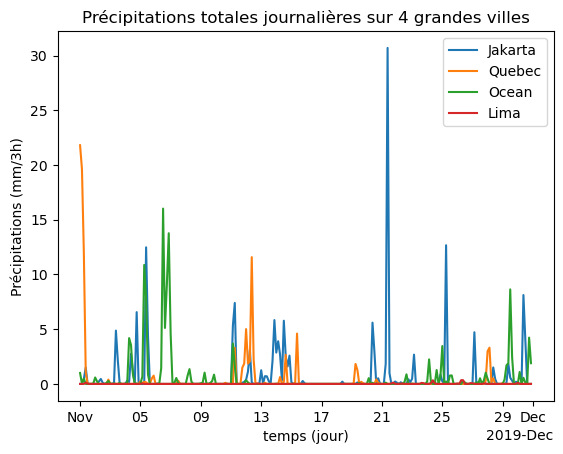

In [6]:
Jakarta.plot(label="Jakarta")
Quebec.plot(label="Quebec")
Ocean.plot(label="Ocean")
Lima.plot(label="Lima")
#graphique des précipitations en fonction du temps. 
plt.ylabel("Précipitations (mm/3h)")
plt.xlabel("temps (jour)")
plt.title("Précipitations totales journalières sur 4 grandes villes")
plt.legend()
plt.savefig("3a", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
#3. Cumul par mois
Jakarta = ds["precipitationCal"].sel(lon=JakartaLon, lat=JakartaLat)
Quebec = ds["precipitationCal"].sel(lon=QuebecLon, lat=QuebecLat)
Ocean = ds["precipitationCal"].sel(lon=OceanLon, lat=OceanLat)
Lima = ds["precipitationCal"].sel(lon=LimaLon, lat=LimaLat)

total_mois_J=Jakarta.sum()
total_mois_Q=Quebec.sum()
total_mois_O=Ocean.sum()
total_mois_L=Lima.sum()

print("le total pour jakarta est de:",total_mois_J.item(), "mm")
print("le total pour Quebec est de:",total_mois_Q.item(), "mm")
print("le total pour Ocean est de:",total_mois_O.item(), "mm")
print("le total pour Lima est de:",total_mois_L.item(), "mm")

le total pour jakarta est de: 173.991943359375 mm
le total pour Quebec est de: 106.27792358398438 mm
le total pour Ocean est de: 130.98695373535156 mm
le total pour Lima est de: 2.120729923248291 mm


In [10]:
#b)calcul du nombre de jour avec de la pluie pour chaque ville. boucle où on ajoute 1 quand precip > 0.
countJ=0
PrecipZeroPlusJ=[]
countQ=0
PrecipZeroPlusQ=[]
countO=0
PrecipZeroPlusO=[]
countL=0
PrecipZeroPlusL=[]
for i in Jakarta:
    if i > 0:
        countJ +=1
        PrecipZeroPlusJ.append(i)
for i in Quebec:
    if i > 0:
        countQ +=1
        PrecipZeroPlusQ.append(i)
for i in Ocean:
    if i > 0:
        countO +=1
        PrecipZeroPlusO.append(i)
for i in Lima:
    if i > 0:
        countL +=1
        PrecipZeroPlusL.append(i)
print("mesure > 0 Jakarta: ", countJ)
print("mesure > 0 Quebec: ", countQ)
print("mesure > 0 Ocean: ",countO)
print("mesure > 0 Lima: ",countL)
fréquenceJ=countJ/240*100
fréquenceQ=countQ/240*100
fréquenceO=countO/240*100
fréquenceL=countL/240*100
print("fréquence jakarta = ",fréquenceJ)
print("fréquence Quebec = ",fréquenceQ)
print("fréquence Ocean = ",fréquenceO)
print("fréquence Lima = ",fréquenceL)

mesure > 0 Jakarta:  100
mesure > 0 Quebec:  61
mesure > 0 Ocean:  99
mesure > 0 Lima:  29
fréquence jakarta =  41.66666666666667
fréquence Quebec =  25.416666666666664
fréquence Ocean =  41.25
fréquence Lima =  12.083333333333334


In [29]:
#c)moyenne en tenant compte de toutes les pas de temps (240)

total_mois_JM=total_mois_J.values/240
total_mois_QM=total_mois_Q.values/240
total_mois_OM=total_mois_O.values/240
total_mois_LM=total_mois_L.values/240

#moyenne en rejetant les heures sans pluie. 
moyennePosJ=np.mean(PrecipZeroPlusJ)
moyennePosQ=np.mean(PrecipZeroPlusQ)
moyennePosO=np.mean(PrecipZeroPlusO)
moyennePosL=np.mean(PrecipZeroPlusL)


print("precip moyenne Jakarta:", total_mois_JM)
print("precip moyenne Quebec:", total_mois_QM)
print("precip moyenne Ocean:", total_mois_OM)
print("precip moyenne Lima:", total_mois_LM)

print("precip moyenne > 0 Jakarta:", moyennePosJ)
print("precip moyenne 0 > Quebec:", moyennePosQ)
print("precip moyenne 0 > Ocean:", moyennePosO)
print("precip moyenne 0 > Lima:", moyennePosL)

precip moyenne Jakarta: 0.7249664306640625
precip moyenne Quebec: 0.4428246815999349
precip moyenne Ocean: 0.5457789738972981
precip moyenne Lima: 0.008836374680201212
precip moyenne > 0 Jakarta: 1.7399195
precip moyenne 0 > Quebec: 1.7422608
precip moyenne 0 > Ocean: 1.3231004
precip moyenne 0 > Lima: 0.073128626


In [12]:
#d) boucle pour calculer la suite d'heures avec de la pluie. Tant que les valeurs sont différentes de 0 on ajoute 1 au compte. Lorsque l'on rencontre un 0 on reset la comptage et ajoute la valeur dans notre liste. On sélectionne ensuite le maximum.

suiteJ=0
suiteJlist=[]
for i in Jakarta:
    if i != 0:
        suiteJ += 1      
    else:
        suiteJlist.append(suiteJ)
        suiteJ=0
suiteQ=0
suiteQlist=[]
for i in Quebec:
    if i != 0:
        suiteQ += 1      
    else:
        suiteQlist.append(suiteQ)
        suiteQ=0
suiteO=0
suiteOlist=[]
for i in Ocean:
    if i != 0:
        suiteO += 1      
    else:
        suiteOlist.append(suiteO)
        suiteO=0
suiteL=0
suiteLlist=[]
for i in Lima:
    if i != 0:
        suiteL += 1      
    else:
        suiteLlist.append(suiteL)
        suiteL=0
MaxJourJ=max(suiteJlist)
MaxJourQ=max(suiteQlist)
MaxJourO=max(suiteOlist)
MaxJourL=max(suiteLlist)

print("nbr de groupes de 3 heures de pluie max Jakarta:", MaxJourJ)
print("nbr de groupes de 3 de pluie max Quebec:", MaxJourQ)
print("nbr de groupes de 3 de pluie max Ocean:", MaxJourO)
print("nbr de groupes de 3 de pluie max Lima:", MaxJourL)

nbr journée de pluie max Jakarta: 12
nbr journée de pluie max Quebec: 9
nbr journée de pluie max Ocean: 12
nbr journée de pluie max Lima: 4


In [13]:
#e)Maximums des villes 

MaxPrecipJ=Jakarta.max()
MaxPrecipQ=Quebec.max()
MaxPrecipO=Ocean.max()
MaxPrecipL=Lima.max()

print("max precip Jakarta:", MaxPrecipJ.item())
print("max precip Quebec:", MaxPrecipQ.item())
print("max precip ocean:", MaxPrecipO.item())
print("max precip Lima:", MaxPrecipL.item())

max precip Jakarta: 30.70304298400879
max precip Quebec: 21.811660766601562
max precip ocean: 16.0211181640625
max precip Lima: 0.3448418080806732


In [12]:
#f)
distance=0.5 #environ 50km en degrés

#identification des points voisins - méthode nearest pour sélectionner les points qui ne tombent pas directement sur une valeur de la grille.
JakartaN = ds["precipitationCal"].sel(lon=JakartaLon, lat=JakartaLat+distance, method="nearest")
JakartaS = ds["precipitationCal"].sel(lon=JakartaLon, lat=JakartaLat-distance, method="nearest")
JakartaE = ds["precipitationCal"].sel(lon=JakartaLon+distance, lat=JakartaLat, method="nearest")
JakartaO = ds["precipitationCal"].sel(lon=JakartaLon-distance, lat=JakartaLat, method="nearest")

QuebecN = ds["precipitationCal"].sel(lon=QuebecLon, lat=QuebecLat+distance, method="nearest")
QuebecS = ds["precipitationCal"].sel(lon=QuebecLon, lat=QuebecLat-distance, method="nearest")
QuebecE = ds["precipitationCal"].sel(lon=QuebecLon+distance, lat=QuebecLat, method="nearest")
QuebecO = ds["precipitationCal"].sel(lon=QuebecLon-distance, lat=QuebecLat, method="nearest")

OceanN = ds["precipitationCal"].sel(lon=OceanLon, lat=OceanLat+distance, method="nearest")
OceanS = ds["precipitationCal"].sel(lon=OceanLon, lat=OceanLat-distance, method="nearest")
OceanE = ds["precipitationCal"].sel(lon=OceanLon+distance, lat=OceanLat, method="nearest")
OceanO = ds["precipitationCal"].sel(lon=OceanLon-distance, lat=OceanLat, method="nearest")

LimaN = ds["precipitationCal"].sel(lon=LimaLon, lat=LimaLat+distance, method="nearest")
LimaS = ds["precipitationCal"].sel(lon=LimaLon, lat=LimaLat-distance, method="nearest")
LimaE = ds["precipitationCal"].sel(lon=LimaLon+distance, lat=LimaLat, method="nearest")
LimaO = ds["precipitationCal"].sel(lon=LimaLon-distance, lat=LimaLat, method="nearest")

# 1. Empiler les séries en un tableau 2D (5 lignes x 240 colonnes)
donneesJ = np.array([Jakarta.values, JakartaN.values, JakartaS.values, JakartaE.values, JakartaO.values])
donneesQ = np.array([Quebec.values, QuebecN.values, QuebecS.values, QuebecE.values, QuebecO.values])
donneesO = np.array([Ocean.values, OceanN.values, OceanS.values, OceanE.values, OceanO.values])
donneesL = np.array([Lima.values, LimaN.values, LimaS.values, LimaE.values, LimaO.values])

# 2. Calculer la matrice de corrélation (seulement la première ligne nous intéresse pour les coefficients du point avec ses voisins, on ignore le point 0,0 qui est le coefficient ave clui-même=toujours 1)
matrice_corrJ = np.corrcoef(donneesJ)
r_NordJ   = matrice_corrJ[0, 1] 
r_SudJ = matrice_corrJ[0, 2]  
r_EstJ   = matrice_corrJ[0, 3]  
r_OuestJ  = matrice_corrJ[0, 4]  

matrice_corrQ = np.corrcoef(donneesQ)
r_NordQ   = matrice_corrQ[0, 1] 
r_SudQ = matrice_corrQ[0, 2]  
r_EstQ   = matrice_corrQ[0, 3]  
r_OuestQ  = matrice_corrQ[0, 4]  

matrice_corrO = np.corrcoef(donneesO)
r_NordO   = matrice_corrO[0, 1] 
r_SudO = matrice_corrO[0, 2]  
r_EstO   = matrice_corrO[0, 3]  
r_OuestO = matrice_corrO[0, 4]  

matrice_corrL = np.corrcoef(donneesL)
r_NordL   = matrice_corrL[0, 1] 
r_SudL = matrice_corrL[0, 2]  
r_EstL   = matrice_corrL[0, 3]  
r_OuestL  = matrice_corrL[0, 4]  

In [13]:
print(r_NordJ)
print(r_SudJ)
print(r_EstJ)
print(r_OuestJ)
print("fin jakarta format N,S,E,O du haut vers le bas")
print(r_NordQ)
print(r_SudQ)
print(r_EstQ)
print(r_OuestQ)
print("fin Quebec format N,S,E,O du haut vers le bas")
print(r_NordO)
print(r_SudO)
print(r_EstO)
print(r_OuestO)
print("fin Ocean format N,S,E,O du haut vers le bas")
print(r_NordL)
print(r_SudL)
print(r_EstL)
print(r_OuestL)
print("fin Lima format N,S,E,O du haut vers le bas")

0.017729673600218585
0.1630605663889774
0.16830721206657354
0.16534475951437838
fin jakarta format N,S,E,O du haut vers le bas
0.9101663836366778
0.8796040396280328
0.9399452985769431
0.9073001374428552
fin Quebec format N,S,E,O du haut vers le bas
0.3628662754133897
0.4396465746731611
0.6523089885023428
0.6733030470014728
fin Ocean format N,S,E,O du haut vers le bas
0.5166846897172637
-0.016449881044693946
0.019259436306522312
-0.05501349168767263
fin Lima format N,S,E,O du haut vers le bas


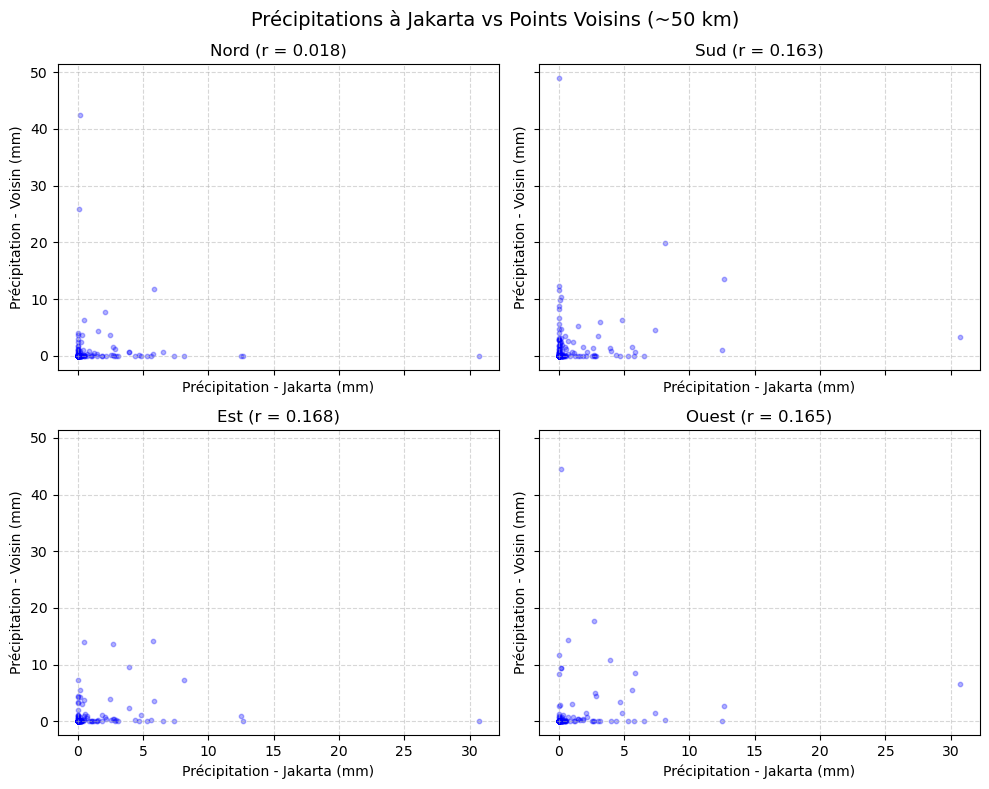

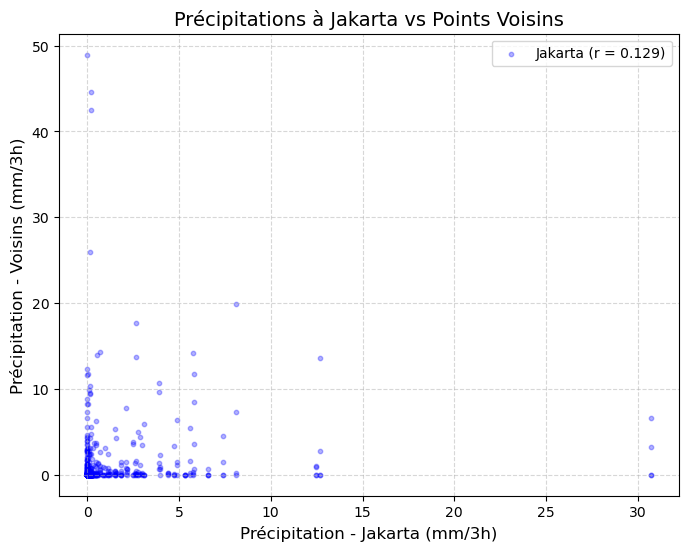

In [75]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Combiner les voisins avec concatenate. la liste combiné devient, 240 valeurs de N, 240 valeurs de S, etc
voisins_combinesJ = np.concatenate([JakartaN.values, JakartaS.values, JakartaE.values, JakartaO.values])


# Répéter les valeurs de Jakarta 4 fois pour correspondre à chaque voisin
jakarta_repete = np.tile(Jakarta.values, 4)
#calcul coefficient moyen
r_GlobalJ=(r_NordJ+r_SudJ+r_EstJ+r_OuestJ)/4


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(jakarta_repete, voisins_combinesJ, alpha=0.3, s=10, color='blue',label=f"Jakarta (r = {r_GlobalJ:.3f})")


# graphique scatter plot  
ax.set_title("Précipitations à Jakarta vs Points Voisins", fontsize=14)
ax.set_xlabel("Précipitation - Jakarta (mm/3h)", fontsize=12)
ax.set_ylabel("Précipitation - Voisins (mm/3h)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.savefig("3fJ", dpi=300, bbox_inches="tight")
plt.show()

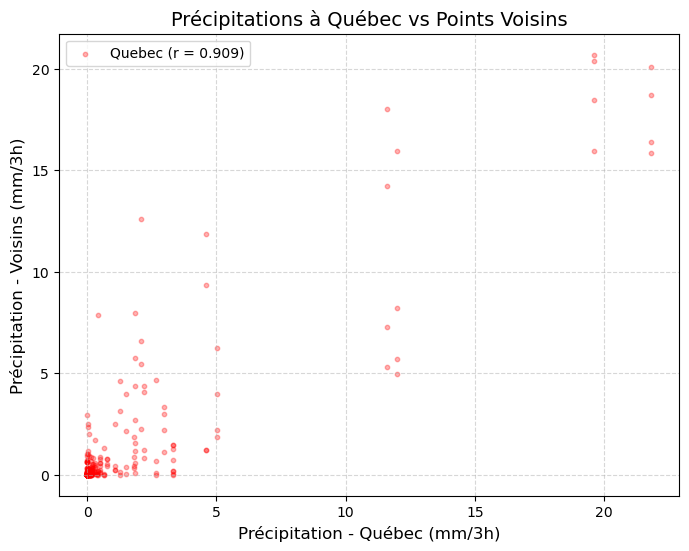

In [76]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Combiner les voisins avec concatenate. la liste combiné devient, 240 valeurs de N, 240 valeurs de S, etc
voisins_combinesQ = np.concatenate([QuebecN.values, QuebecS.values, QuebecE.values, QuebecO.values])


# Répéter les valeurs de Jakarta 4 fois pour correspondre à chaque voisin

Quebec_repete = np.tile(Quebec.values, 4)
#calcul coefficient moyen
r_GlobalQ=(r_NordQ+r_SudQ+r_EstQ+r_OuestQ)/4




fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Quebec_repete, voisins_combinesQ, alpha=0.3, s=10, color='red',label=f"Quebec (r = {r_GlobalQ:.3f})")

# graphique scatter plot 
ax.set_title("Précipitations à Québec vs Points Voisins", fontsize=14)
ax.set_xlabel("Précipitation - Québec (mm/3h)",fontsize=12)
ax.set_ylabel("Précipitation - Voisins (mm/3h)",fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.savefig("3fQ", dpi=300, bbox_inches="tight")
plt.show()

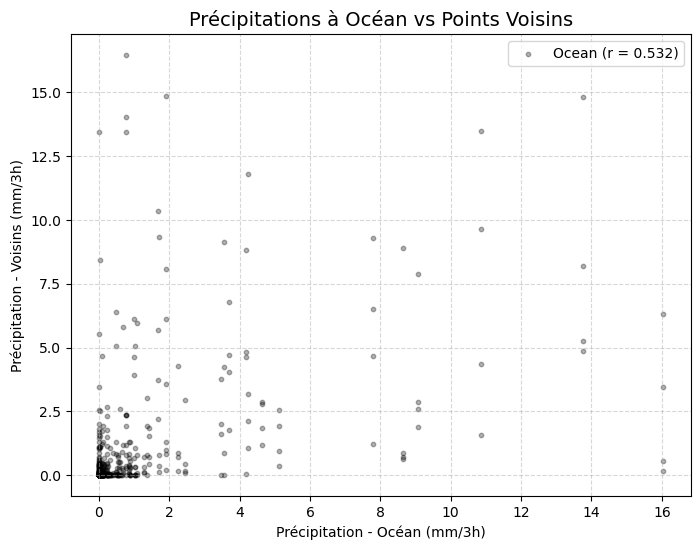

In [33]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Combiner les voisins avec concatenate. la liste combiné devient, 240 valeurs de N, 240 valeurs de S, etc
voisins_combinesO = np.concatenate([OceanN.values, OceanS.values, OceanE.values, OceanO.values])


# Répéter les valeurs de Jakarta 4 fois pour correspondre à chaque voisin


Ocean_repete = np.tile(Ocean.values, 4)
#calcul coefficient moyen
r_GlobalO=(r_NordO+r_SudO+r_EstO+r_OuestO)/4


fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(Ocean_repete, voisins_combinesO, alpha=0.3, s=10, color='black',label=f"Ocean (r = {r_GlobalO:.3f})")


# graphique scatter plot 
ax.set_title("Précipitations à Océan vs Points Voisins", fontsize=14)
ax.set_xlabel("Précipitation - Océan (mm/3h)")
ax.set_ylabel("Précipitation - Voisins (mm/3h)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.savefig("3fO", dpi=300, bbox_inches="tight")
plt.show()

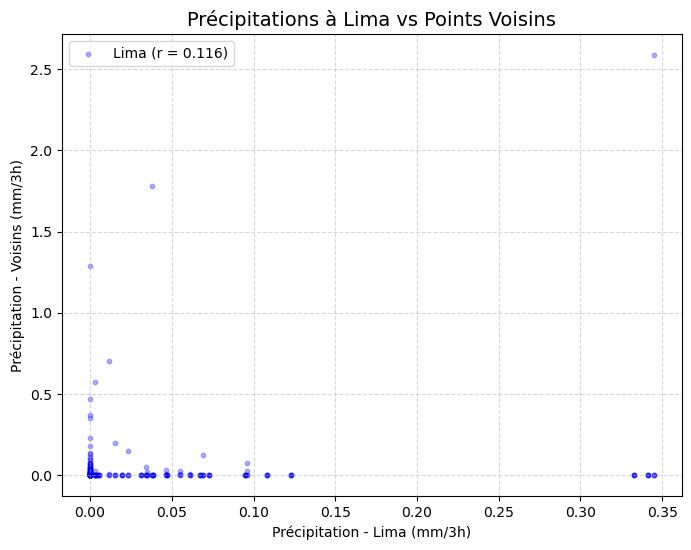

In [34]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Combiner les voisins avec concatenate. la liste combiné devient, 240 valeurs de N, 240 valeurs de S, etc
voisins_combinesL = np.concatenate([LimaN.values, LimaS.values, LimaE.values, LimaO.values])

# Répéter les valeurs de Jakarta 4 fois pour correspondre à chaque voisin

Lima_repete = np.tile(Lima.values, 4)
#calcul coefficient moyen
r_GlobalL=(r_NordL+r_SudL+r_EstL+r_OuestL)/4



fig, ax = plt.subplots(figsize=(8, 6))

# graphique scatter plot 
ax.scatter(Lima_repete, voisins_combinesL, alpha=0.3, s=10, color='blue',label=f"Lima (r = {r_GlobalL:.3f})")
ax.set_title("Précipitations à Lima vs Points Voisins", fontsize=14)
ax.set_xlabel("Précipitation - Lima (mm/3h)")
ax.set_ylabel("Précipitation - Voisins (mm/3h)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.savefig("3fL", dpi=300, bbox_inches="tight")
plt.show()

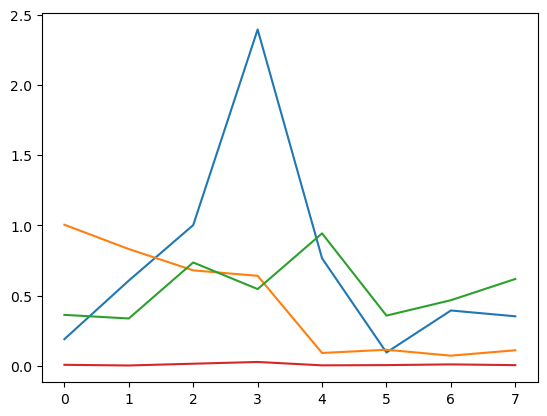

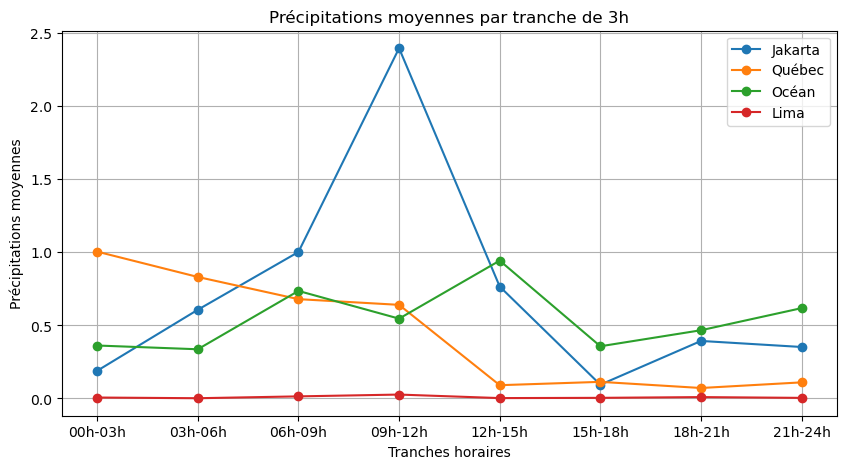

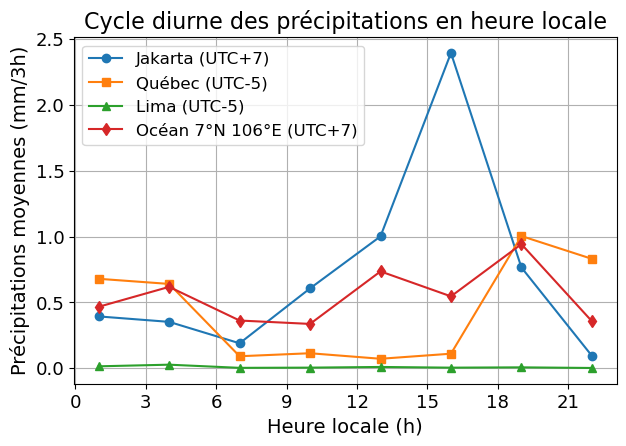

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

#initialisation des listes qui vont contenir les caleurs pour chaque groupe d'heures 
liste0=list(range(0, 240, 8))
liste1=list(range(1, 240, 8))
liste2=list(range(2, 240, 8))
liste3=list(range(3, 240, 8))
liste4=list(range(4, 240, 8))
liste5=list(range(5, 240, 8))
liste6=list(range(6, 240, 8))
liste7=list(range(7, 240, 8))
num=[0,1,2,3,4,5,6,7]
precip_moyJ=[]
precip_moyQ=[]
precip_moyO=[]
precip_moyL=[]
# initialisation de la boucle pour passer chaque liste une à une pour chaque ville. les 30 premières valeurs correspondent à UTC=0, 30 prochaines UTC=3 etc. 
for j in num:
    current_list = globals()[f"liste{j}"]
    for i in current_list:
        precip_moyJ.append(Jakarta[i])
        precip_moyQ.append(Quebec[i])
        precip_moyO.append(Ocean[i])
        precip_moyL.append(Lima[i])
#calcul de la moyenne pour chaque groupe d'heures        
JakartaMoyPrecip = [np.mean(precip_moyJ[0:30]),np.mean(precip_moyJ[30:60]),np.mean(precip_moyJ[60:90]),np.mean(precip_moyJ[90:120]),np.mean(precip_moyJ[120:150]),np.mean(precip_moyJ[150:180]),np.mean(precip_moyJ[180:210]),np.mean(precip_moyJ[210:240])]
QuebecMoyPrecip = [np.mean(precip_moyQ[0:30]),np.mean(precip_moyQ[30:60]),np.mean(precip_moyQ[60:90]),np.mean(precip_moyQ[90:120]),np.mean(precip_moyQ[120:150]),np.mean(precip_moyQ[150:180]),np.mean(precip_moyQ[180:210]),np.mean(precip_moyQ[210:240])]
OceanMoyPrecip = [np.mean(precip_moyO[0:30]),np.mean(precip_moyO[30:60]),np.mean(precip_moyO[60:90]),np.mean(precip_moyO[90:120]),np.mean(precip_moyO[120:150]),np.mean(precip_moyO[150:180]),np.mean(precip_moyO[180:210]),np.mean(precip_moyO[210:240])]
LimaMoyPrecip = [np.mean(precip_moyL[0:30]),np.mean(precip_moyL[30:60]),np.mean(precip_moyL[60:90]),np.mean(precip_moyL[90:120]),np.mean(precip_moyL[120:150]),np.mean(precip_moyL[150:180]),np.mean(precip_moyL[180:210]),np.mean(precip_moyL[210:240])]


# 1. Décalage direct des heures par rapport à UTC
Jakarta_local = Jakarta.assign_coords(time=Jakarta.time + pd.Timedelta(hours=7))  # UTC+7
Quebec_local = Quebec.assign_coords(time=Quebec.time - pd.Timedelta(hours=5))  # UTC-5
Lima_local = Lima.assign_coords(time=Lima.time - pd.Timedelta(hours=5))  # UTC-5
Ocean_local = Ocean.assign_coords(time=Ocean.time + pd.Timedelta(hours=7))  # UTC+7

# 2. Groupby
JakartaMoyPrecip = Jakarta_local.groupby("time.hour").mean()
QuebecMoyPrecip = Quebec_local.groupby("time.hour").mean()
LimaMoyPrecip = Lima_local.groupby("time.hour").mean()
OceanMoyPrecip = Ocean_local.groupby("time.hour").mean()

# 3.graphique
plt.figure(figsize=(7, 4.5))
plt.plot(
    JakartaMoyPrecip.hour, JakartaMoyPrecip, label="Jakarta (UTC+7)", marker="o"
)
plt.plot(
    QuebecMoyPrecip.hour, QuebecMoyPrecip, label="Québec (UTC-5)", marker="s"
)
plt.plot(LimaMoyPrecip.hour, LimaMoyPrecip, label="Lima (UTC-5)", marker="^")
plt.plot(OceanMoyPrecip.hour,OceanMoyPrecip,label="Océan 7°N 106°E (UTC+7)", marker="d",)

# Tailles de polices augmentées pour rapport
plt.xlabel("Heure locale (h)", fontsize=14)
plt.ylabel("Précipitations moyennes (mm/3h)", fontsize=14)
plt.title("Cycle diurne des précipitations en heure locale", fontsize=16)
plt.xticks([0, 3, 6, 9, 12, 15, 18, 21], fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=12)

plt.grid(True)
plt.savefig("4.png", dpi=300, bbox_inches="tight")
plt.show()

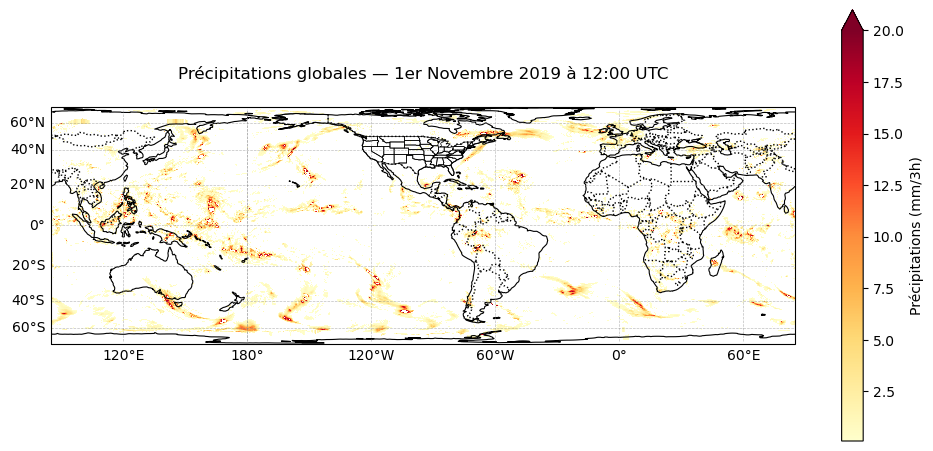

In [62]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

#Sélection des données pour le 1er novembre 2019, seulement les valeurs en bas de 20 mm/3h
ds_temps = ds["precipitationCal"].sel(time="2019-11-01T12:00:00.000000000")
Nov1_12h = ds_temps.where(ds_temps <= 20)

# Configuration des couleurs pour la figure
cmap = plt.colormaps["YlOrRd"].copy()
cmap.set_under(color="none", alpha=0.0)

# Figure et projection créé
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.LambertCylindrical(central_longitude=-95))
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

# Quadrillage avec chiffres des latitudes/longitudes
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
# Désactiver l'affichage des étiquettes en haut et à droite pour ne pas surcharger la carte
gl.top_labels = False
gl.right_labels = False

# graphique pcolormesh
pcm = ax.pcolormesh(
    lon,
    lat,
    Nov1_12h,
    shading="nearest",
    cmap=cmap,
    vmin=0.1,
    vmax=20,
    transform=ccrs.PlateCarree(),
)

plt.colorbar(pcm, ax=ax, label="Précipitations (mm/3h)", shrink=0.7, extend="max")
plt.title("Précipitations globales — 1er Novembre 2019 à 12:00 UTC", pad=20)

plt.savefig("2,1.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: applied function returned data with an unexpected number of dimensions. Received 1 dimension(s) but expected 0 dimensions with names (), from:

array([ True,  True,  True, ...,  True,  True,  True])

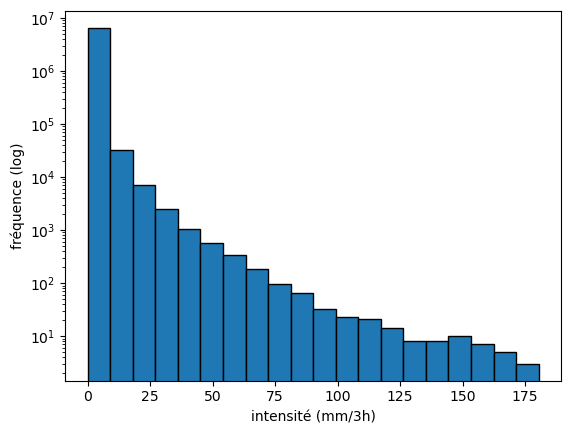

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


values = ds_temps.values
counts, bin_edges = np.histogram(values, bins=20)

# pour faire un bel histogramme
widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + widths / 2

# histogramme
plt.bar(bin_centers, counts, width=widths, edgecolor='black', align='center')
plt.xlabel("intensité (mm/3h)")
plt.ylabel("fréquence (log)")
plt.yscale("log")
plt.savefig("2,2log", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Henri\AppData\Local\Temp\ipykernel_19748\3211449773.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd').copy()


ValueError: NumPy boolean array indexing assignment cannot assign 2205607 input values to the 2369942 output values where the mask is true

Error in callback <function _draw_all_if_interactive at 0x0000020E2BD0E980> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'Colorbar' object has no attribute '_boundaries'

AttributeError: 'Colorbar' object has no attribute '_boundaries'

<Figure size 1200x800 with 2 Axes>

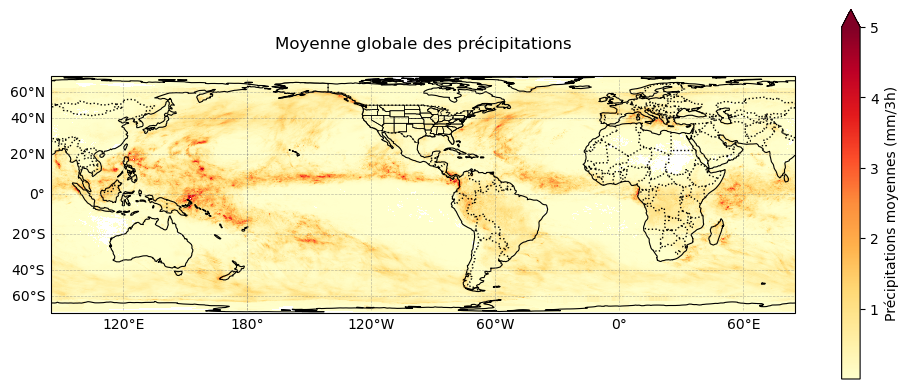

In [61]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# 1. moyenne des précipitations sur tout le mois sur tout le globe
precip = ds["precipitationCal"]
moy_globale = precip.mean(dim="time")
moy_0_5 = moy_globale.where((moy_globale > 0) & (moy_globale < 5))

# 4. Configuration de la colormap
cmap = plt.colormaps["YlOrRd"].copy()
cmap.set_under(color="none", alpha=0.0)

# 5. Figure et projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.LambertCylindrical(central_longitude=-95))
ax.set_global()

# 6. Éléments géographiques et quadrillage
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

# 7. Tracé avec pcolormesh
pcm = ax.pcolormesh(
    lon,
    lat,
    moy_0_5.values,
    shading="nearest",
    cmap=cmap,
    vmin=0.0001,  # Rends transparents les pixels filtrés (NaN) ou à 0
    vmax=5,
    transform=ccrs.PlateCarree(),
)

# 8. Colorbar et titres
plt.colorbar(
    pcm,
    ax=ax,
    label="Précipitations moyennes (mm/3h)",
    shrink=0.6,
    extend="max",
)
plt.title(
    "Moyenne globale des précipitations",
    pad=20,
)
plt.savefig("2,3log", dpi=300, bbox_inches="tight")
plt.show()

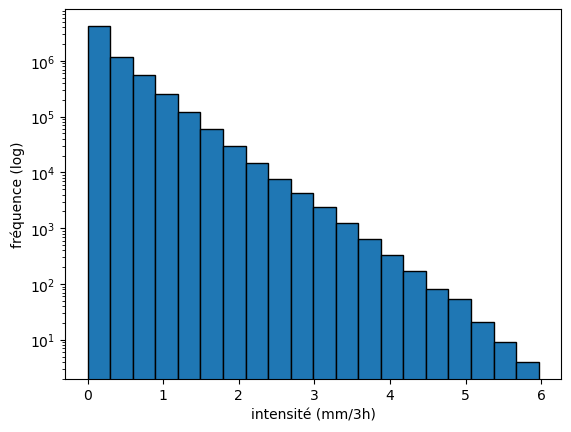

In [7]:
import numpy as np
import matplotlib.pyplot as plt


precip = ds["precipitationCal"]
moy_valeurs = precip.mean(dim="time")
values = moy_valeurs.values



counts, bin_edges = np.histogram(values, bins=20)

# pour faire un bel histogramme
widths = np.diff(bin_edges)
bin_centers = bin_edges[:-1] + widths / 2

# histogramme
plt.bar(bin_centers, counts, width=widths, edgecolor='black', align='center')
plt.xlabel("intensité (mm/3h)")
plt.ylabel("fréquence (log)")
plt.yscale("log")
plt.savefig("2,4log", dpi=300, bbox_inches="tight")
plt.show()

Nombre de valeurs non-NaN : 6293396
Min / Max : 3.135735e-10 4.9433084


C:\Users\Henri\AppData\Local\Temp\ipykernel_15800\436406506.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd').copy()


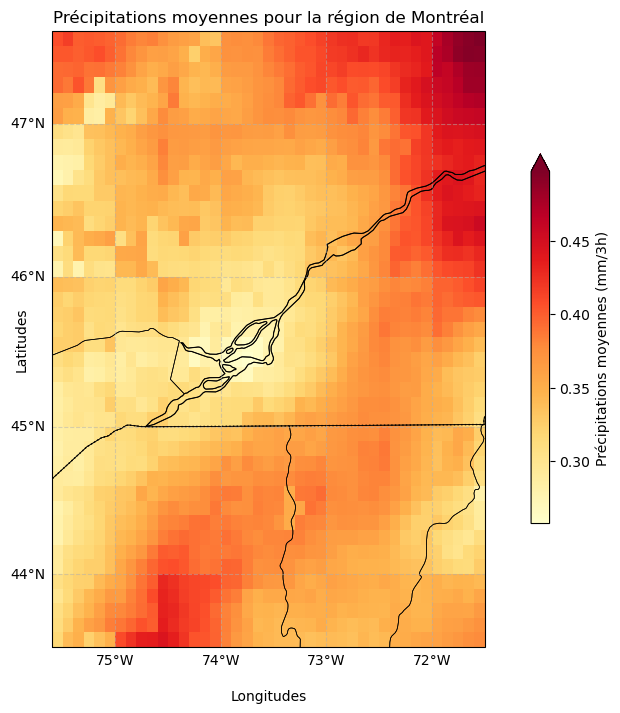

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


precip = ds["precipitationCal"]
# Filtrage par découpage (slice) afin de sélectionner que les données proche de montreal.
precip_mtl = precip.sel(lat=slice(MontrealLat-2, MontrealLat+2),lon=slice(MontrealLon-2, MontrealLon+2))
lon = precip_mtl["lon"]
lat = precip_mtl["lat"]
# 2. Moyenne temporelle
moy_valeurs = precip_mtl.mean(dim="time")

# 3. Configuration des couleurs 
cmap = plt.cm.get_cmap('YlOrRd').copy()
cmap.set_under(color='none', alpha=0.0)

# 4. projection et figure
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator(central_longitude=-95))

# 5. Éléments géographiques
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.5)

# 6. Tracé avec pcolormesh
pcm = ax.pcolormesh(lon, lat, moy_valeurs,cmap=cmap,transform=ccrs.PlateCarree())

# 7. Colorbar et étiquettes
plt.colorbar(pcm, ax=ax, label='Précipitations moyennes (mm/3h)', shrink=0.6, extend='max')
plt.title('Précipitations moyennes pour la région de Montréal')
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', alpha=0.5)

# Masquer les étiquettes en haut et à droite pour un rendu propre
gl.top_labels = False
gl.right_labels = False

# Ajuster la taille de la police si besoin
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
ax.text(-0.07, 0.5, 'Latitudes', va='center', ha='center',
        rotation='vertical', transform=ax.transAxes)
ax.text(0.5, -0.08, 'Longitudes', va='center', ha='center',
        transform=ax.transAxes)
plt.savefig("2,5", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Henri\AppData\Local\Temp\ipykernel_19124\3487063482.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd').copy()


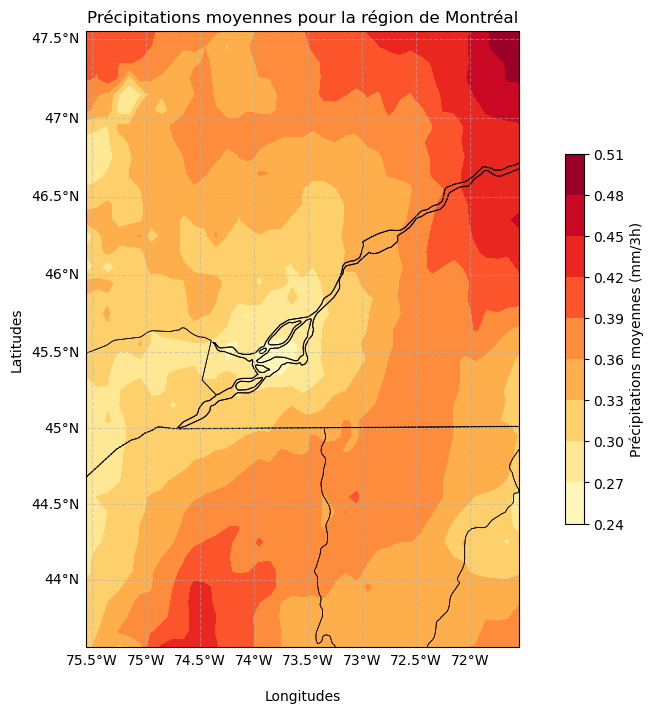

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


precip = ds["precipitationCal"]

# Filtrage par découpage (slice) afin de sélectionner que les données proche de montreal.
precip_mtl = precip.sel(lat=slice(MontrealLat-2, MontrealLat+2),lon=slice(MontrealLon-2, MontrealLon+2))
lon = precip_mtl["lon"]
lat = precip_mtl["lat"]
moy_valeurs = precip_mtl.mean(dim="time")

# 3. Configuration de la colormap
cmap = plt.cm.get_cmap('YlOrRd').copy()
cmap.set_under(color='none', alpha=0.0)

# 4. figure et projection
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.Mercator(central_longitude=-95))

# 5. Éléments géographiques
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linewidth=0.5)

# 6. Tracé avec pcolormesh
pcm = ax.contourf(lon, lat, moy_valeurs,cmap=cmap,transform=ccrs.PlateCarree())

# 7. Colorbar et étiquettes
plt.colorbar(pcm, ax=ax, label='Précipitations moyennes (mm/3h)', shrink=0.6, extend='max')
plt.title('Précipitations moyennes pour la région de Montréal')
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', alpha=0.5)

# Masquer les étiquettes en haut et à droite pour un rendu propre
gl.top_labels = False
gl.right_labels = False

# Ajuster la taille de la police si besoin
#gl.xlabel_style = {'size': 10}
#gl.ylabel_style = {'size': 10}
ax.text(-0.16,0.5,"Latitudes",va="center",ha="center",rotation="vertical",transform=ax.transAxes,)
ax.text(0.5, -0.08, 'Longitudes', va='center', ha='center',
        transform=ax.transAxes)
plt.savefig("2,6", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
from prettytable import PrettyTable

# Définition des colonnes
matable = PrettyTable([
    "",
    "Jakarta",
    "Quebec",
    "Ocean",
    "Lima"
])

#Définition des lignes
matable.add_row([
    "Accumulation totale de précipitation (mm)",
    "173.99",
    "106.28",
    "130.99",
    "2.12"
])

matable.add_row([
    "Fréquence de précipitation (%)",
    "41.67",
    "25.42",
    "41.25",
    "12.08"
])

matable.add_row([
    "Précipitation moyenne (mm/3h)",
    "0.72",
    "0.44",
    "0.54",
    "0.0088"
])

matable.add_row([
    "Intensité de précipitation moyenne (mm/3h)",
    "1.74",
    "1.74",
    "1.32",
    "0.073"
])

matable.add_row([
    "Durée maximale (h)",
    "36",
    "27",
    "36",
    "12"
])

matable.add_row([
    "Valeur maximale (mm)",
    "30.70",
    "21.81",
    "16.021",
    "0.34"
])
# Option A : Afficher directement le code LaTeX dans la console
#print(matable.get_latex_string())

    
print(matable)

\begin{tabular}{ccccc}
 & Jakarta & Quebec & Ocean & Lima \\
Accumulation totale de précipitation (mm) & 173.99 & 106.28 & 130.99 & 2.12 \\
Fréquence de précipitation (%) & 41.67 & 25.42 & 41.25 & 12.08 \\
Précipitation moyenne (mm/3h) & 0.72 & 0.44 & 0.54 & 0.0088 \\
Intensité de précipitation moyenne (mm/3h) & 1.74 & 1.74 & 1.32 & 0.073 \\
Durée maximale (h) & 36 & 27 & 36 & 12 \\
Valeur maximale (mm) & 30.70 & 21.81 & 16.021 & 0.34 \\
\end{tabular}
+--------------------------------------------+---------+--------+--------+--------+
|                                            | Jakarta | Quebec | Ocean  |  Lima  |
+--------------------------------------------+---------+--------+--------+--------+
| Accumulation totale de précipitation (mm)  |  173.99 | 106.28 | 130.99 |  2.12  |
|       Fréquence de précipitation (%)       |  41.67  | 25.42  | 41.25  | 12.08  |
|       Précipitation moyenne (mm/3h)        |   0.72  |  0.44  |  0.54  | 0.0088 |
| Intensité de précipitation moyenne (mm

   ---------------------------------------- 0.0/596.7 kB ? eta -:--:--
   --------------------------------------- 596.7/596.7 kB 36.7 MB/s eta 0:00:00
  Attempting uninstall: wcwidth
    Found existing installation: wcwidth 0.2.5
    Uninstalling wcwidth-0.2.5:
      Successfully uninstalled wcwidth-0.2.5
Note: you may need to restart the kernel to use updated packages.


In [45]:
x=3
x

3

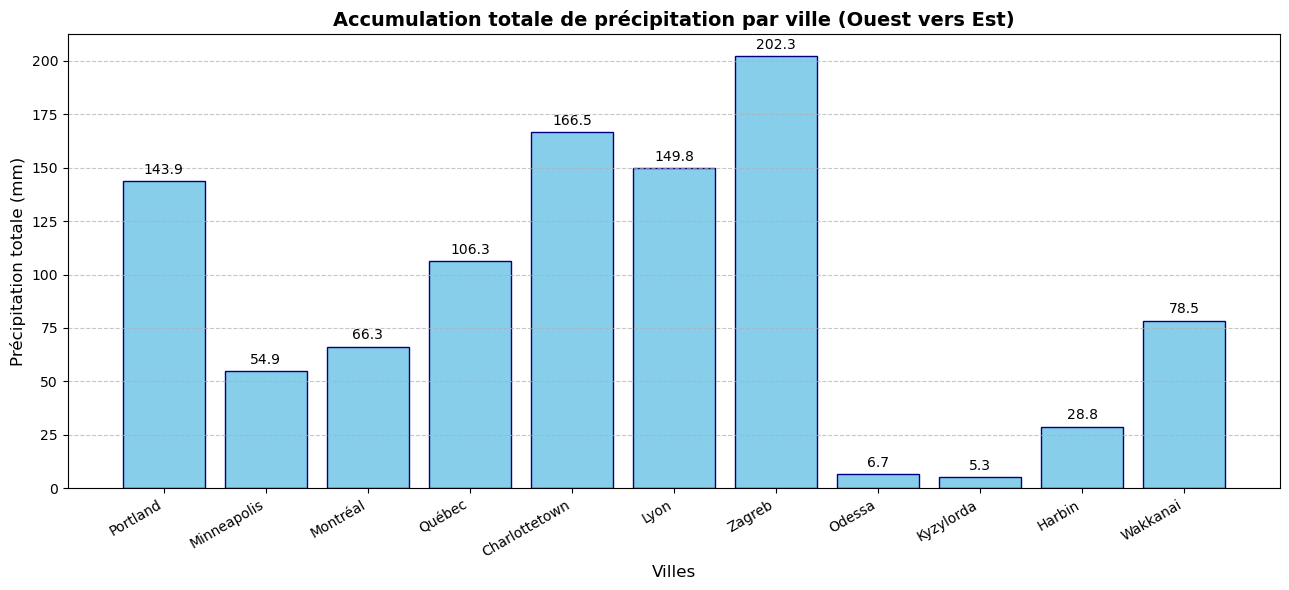

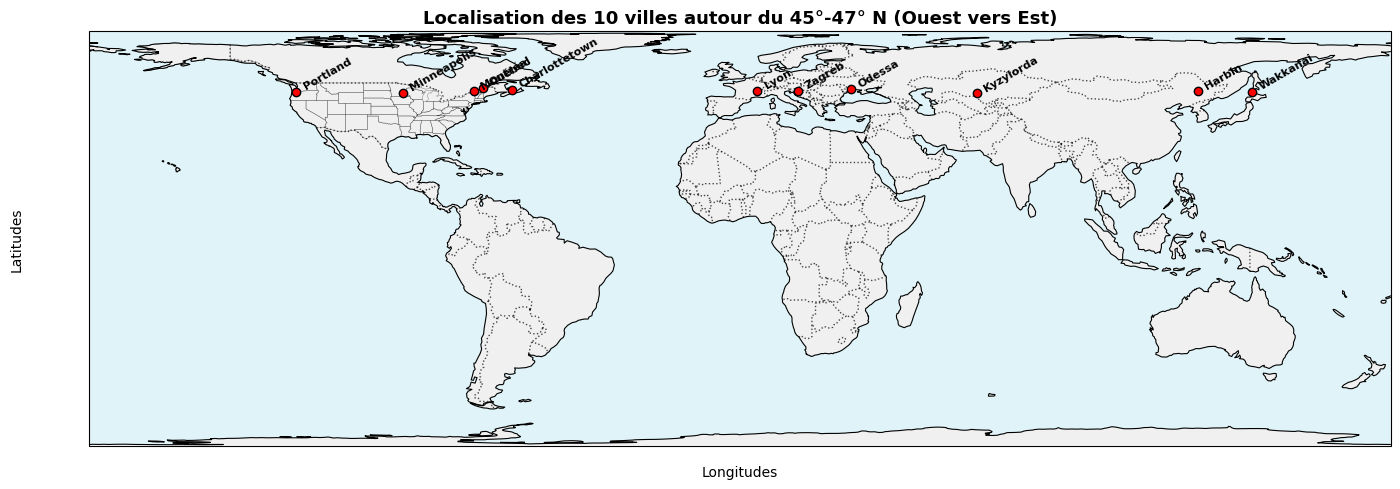

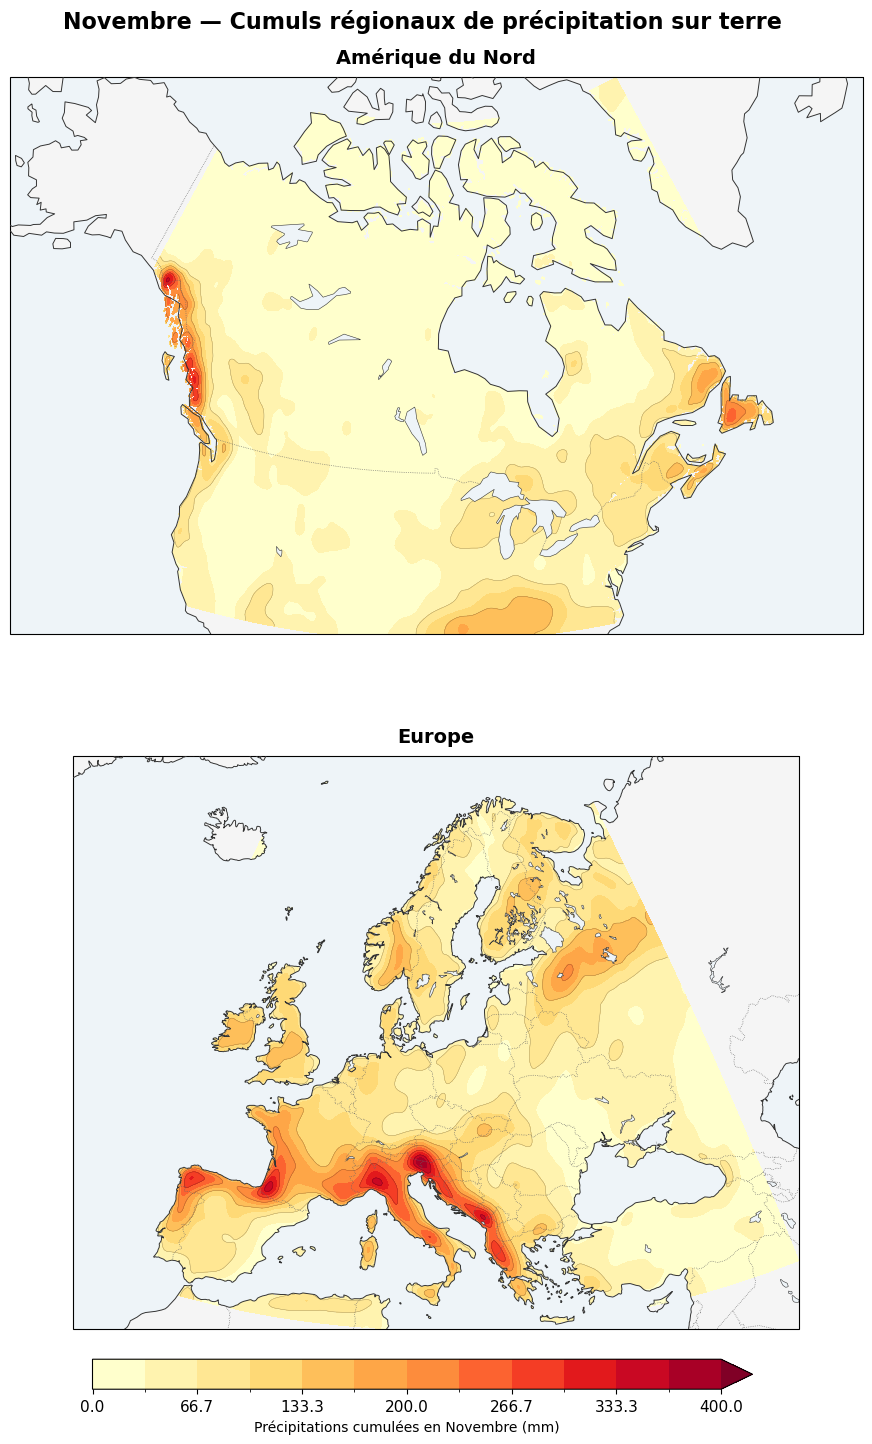

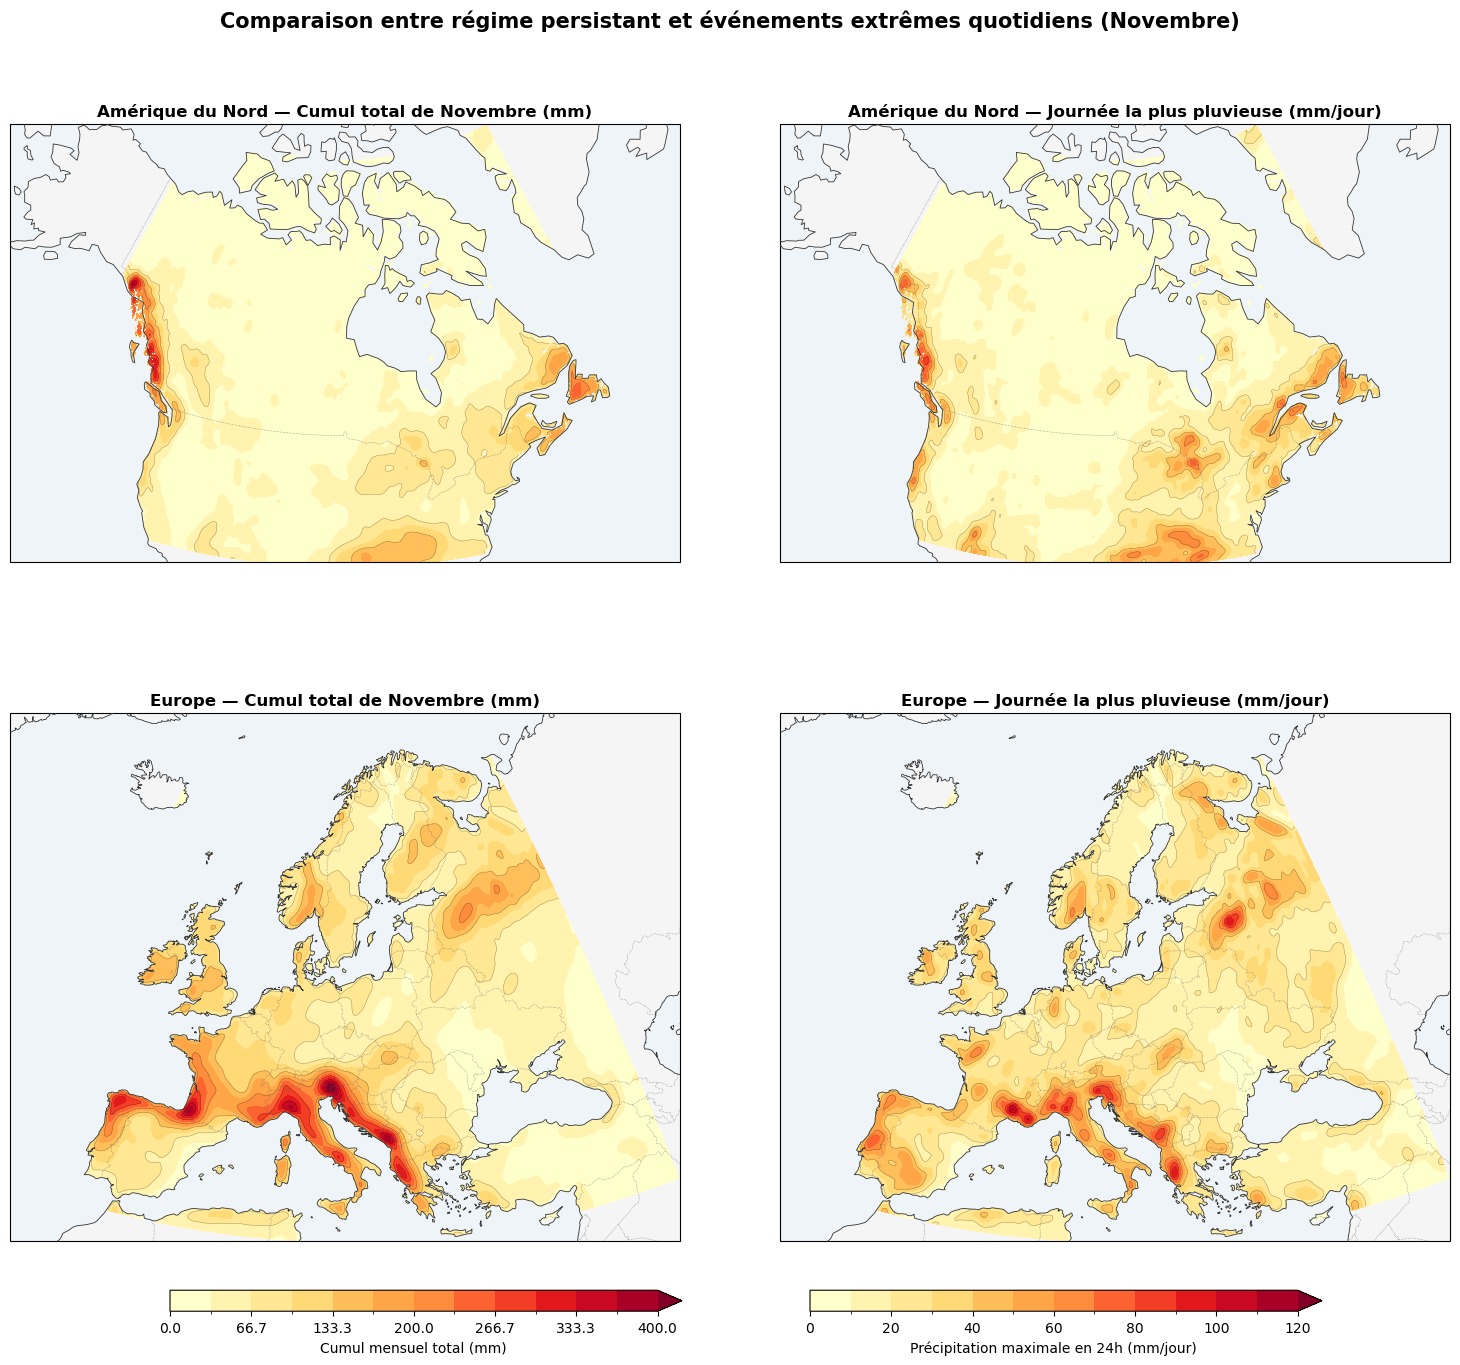

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import xarray as xr

# ==============================================================================
# 1. PRÉPARATION DES DONNÉES (MENSUEL vs MAX QUOTIDIEN)
# ==============================================================================
precip = ds["precipitationCal"]

# A. Cumul mensuel total (mm)
pr_nov_total = precip.sum(dim="time", skipna=True)

# B. Maximum journalier (Rx1day en mm/jour)
# Agrégation par tranche de 24h puis extraction du max quotidien
pr_daily = precip.resample(time="1D").sum(skipna=True)
pr_nov_max_day = pr_daily.max(dim="time", skipna=True)


# ==============================================================================
# 2. MASQUE TERRESTRE ET LISSAGE
# ==============================================================================
def make_land_mask(da_lon, da_lat, scale="50m"):
    land_feature = cfeature.LAND.with_scale(scale)
    geoms = list(land_feature.geometries())

    lon_grid, lat_grid = np.meshgrid(da_lon.values, da_lat.values)
    points = np.vstack((lon_grid.ravel(), lat_grid.ravel())).T
    is_land_flat = np.zeros(len(points), dtype=bool)

    for geom in geoms:
        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = geom.geoms
        else:
            continue

        for poly in polys:
            path = mpath.Path(np.asarray(poly.exterior.coords))
            is_land_flat |= path.contains_points(points)

    return xr.DataArray(
        is_land_flat.reshape(lon_grid.shape), coords={"lat": da_lat, "lon": da_lon}
    )


def process_region_field(da_field, lon_bounds, lat_bounds, sigma=3):
    """Extrait une région, masque les océans et applique un lissage léger."""
    sub = da_field.sel(
        lat=slice(min(lat_bounds), max(lat_bounds)),
        lon=slice(min(lon_bounds), max(lon_bounds)),
    )

    is_land = make_land_mask(sub.lon, sub.lat, scale="50m")
    sub_land = sub.where(is_land)

    data_array = sub_land.fillna(0).values
    smoothed = gaussian_filter(data_array, sigma=sigma)

    return xr.DataArray(smoothed, coords=sub_land.coords).where(is_land)


# Configuration des 2 domaines
regions = {"Amérique du Nord": {"lon": [-140, -50],"lat": [35, 75],"proj": ccrs.LambertConformal(central_longitude=-95, central_latitude=55),"extent": [-140, -50, 35, 75],},
"Europe": {"lon": [-15, 45],"lat": [35, 72],"proj": ccrs.Stereographic(central_longitude=15, central_latitude=55),"extent": [-15, 45, 35, 72],},}

# Calcul des champs lissés pour le cumul mensuel et le max quotidien
processed_data = {}
for rname, rcfg in regions.items():
    processed_data[rname] = {
        "total": process_region_field(
            pr_nov_total, rcfg["lon"], rcfg["lat"], sigma=3
        ),
        "max_day": process_region_field(
            pr_nov_max_day, rcfg["lon"], rcfg["lat"], sigma=3
        ),
    }

# ==============================================================================
# 3. CARTOGRAPHIE 2x2 (TOTAL MENSUEL vs MAX QUOTIDIEN)
# ==============================================================================
fig = plt.figure(figsize=(16, 14))

# Niveaux de contours
levels_total = np.linspace(0, 400, 13)
levels_maxday = np.linspace(0, 120, 13)

row_idx = 0
for rname, rcfg in regions.items():
    # --- Colonne 1 : Cumul mensuel ---
    ax_tot = fig.add_subplot(2, 2, row_idx * 2 + 1, projection=rcfg["proj"])

    for feature in [cfeature.OCEAN, cfeature.LAND]:
        ax_tot.add_feature(
            feature,
            facecolor="#eef4f8" if feature == cfeature.OCEAN else "#f5f5f5",
            zorder=1,
        )
    ax_tot.add_feature(
        cfeature.COASTLINE, linewidth=0.6, edgecolor="#333333", zorder=4
    )
    ax_tot.add_feature(
        cfeature.BORDERS,
        linestyle=":",
        linewidth=0.4,
        edgecolor="#666666",
        zorder=4,
    )

    da_tot = processed_data[rname]["total"]
    cf_tot = da_tot.plot.contourf(
        ax=ax_tot,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        levels=levels_total,
        extend="max",
        zorder=2,
        add_colorbar=False,
    )
    da_tot.plot.contour(
        ax=ax_tot,
        transform=ccrs.PlateCarree(),
        levels=levels_total[::2],
        colors="black",
        linewidths=0.3,
        alpha=0.4,
        zorder=3,
        add_colorbar=False,
    )
    ax_tot.set_extent(rcfg["extent"], crs=ccrs.PlateCarree())
    ax_tot.set_title(
        f"{rname} — Cumul total de Novembre (mm)",
        fontsize=12,
        fontweight="bold",
    )

    # --- Colonne 2 : Journée la plus pluvieuse ---
    ax_max = fig.add_subplot(2, 2, row_idx * 2 + 2, projection=rcfg["proj"])

    for feature in [cfeature.OCEAN, cfeature.LAND]:
        ax_max.add_feature(
            feature,
            facecolor="#eef4f8" if feature == cfeature.OCEAN else "#f5f5f5",
            zorder=1,
        )
    ax_max.add_feature(
        cfeature.COASTLINE, linewidth=0.6, edgecolor="#333333", zorder=4
    )
    ax_max.add_feature(
        cfeature.BORDERS,
        linestyle=":",
        linewidth=0.4,
        edgecolor="#666666",
        zorder=4,
    )

    da_max = processed_data[rname]["max_day"]
    cf_max = da_max.plot.contourf(
        ax=ax_max,
        transform=ccrs.PlateCarree(),
        cmap="YlOrRd",
        levels=levels_maxday,
        extend="max",
        zorder=2,
        add_colorbar=False,
    )
    da_max.plot.contour(
        ax=ax_max,
        transform=ccrs.PlateCarree(),
        levels=levels_maxday[::2],
        colors="black",
        linewidths=0.3,
        alpha=0.4,
        zorder=3,
        add_colorbar=False,
    )
    ax_max.set_extent(rcfg["extent"], crs=ccrs.PlateCarree())
    ax_max.set_title(
        f"{rname} — Journée la plus pluvieuse (mm/jour)",
        fontsize=12,
        fontweight="bold",
    )

    row_idx += 1

# Colorbar 1 (Total)
cax1 = fig.add_axes([0.15, 0.05, 0.32, 0.015])
cb1 = fig.colorbar(cf_tot, cax=cax1, orientation="horizontal")
cb1.set_label("Cumul mensuel total (mm)", fontsize=10)

# Colorbar 2 (Max journalier)
cax2 = fig.add_axes([0.55, 0.05, 0.32, 0.015])
cb2 = fig.colorbar(cf_max, cax=cax2, orientation="horizontal")
cb2.set_label("Précipitation maximale en 24h (mm/jour)", fontsize=10)

plt.suptitle(
    "Comparaison entre régime persistant et événements extrêmes quotidiens (Novembre)",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plt.subplots_adjust(
    left=0.05, right=0.95, top=0.93, bottom=0.1, wspace=0.15, hspace=0.2
)
plt.savefig("bonus", dpi=300, bbox_inches="tight")
plt.show()

<xarray.DataArray 'precipitationCal' (time: 240, lat: 1800, lon: 3600)> Size: 6GB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       ...,

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]],

       [[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2019-11-01 ... 2019-11-30T21:00:00
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
  * lat      (lat) float32 7kB -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
Attributes:
    units:    mm/3h